In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,LSTM ,Dense,Input

# lets import dataset from csv file and clean it , for good processing of model

In [3]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv(
    "/content/reddit_IWantToLearn_100k.csv",
    engine="python"
)

print("Shape:", df.shape)
print(df.head())

Shape: (99609, 1)
                                                text
0  well, i'm no cook, but can't you just quickly ...
1  learn to juggle. think about lolcats. if somet...
2  sounds good, i'll start on the first one right...
3  you can't just post recipes, it doesn't help w...
4  sorry, this doesn't help much, but it may guid...


splitting the train and text data

In [4]:
from sklearn.model_selection import train_test_split
text = df["text"][:1000]
train_texts, temp_texts = train_test_split(
    text,
    test_size=0.2,
    random_state=42)

val_text,test_text = train_test_split(
    temp_texts,
    test_size=0.50,
    random_state=42
)

print("shape of train_texts",len(train_texts)) # list h yeh ab
print("shape of validation_texts",len(val_text))
print("Shape of test texts ",test_text.shape)

shape of train_texts 800
shape of validation_texts 100
Shape of test texts  (100,)


# now we have done with data, now we can do the embedding and tokeinzer

In [5]:
# assigning each word with interger
tokenizer = Tokenizer( num_words=10000,oov_token="<oov>")
tokenized_train = tokenizer.fit_on_texts(train_texts) # The tokenizer learns the vocabulary from the training data only.,as if we do df["text"]--> chance of data leakage si there
print(tokenizer.word_index)
print("Vocabulary for the taken dataset",len(tokenizer.word_index))

{'<oov>': 1, 'the': 2, 'to': 3, 'a': 4, 'you': 5, 'and': 6, 'i': 7, 'of': 8, 'it': 9, 'is': 10, 'in': 11, 'your': 12, 'that': 13, 'for': 14, 'if': 15, 'on': 16, 'have': 17, 'with': 18, 'be': 19, 'but': 20, 'this': 21, 'are': 22, 'or': 23, 'can': 24, 'as': 25, 'do': 26, 'just': 27, 'get': 28, 'my': 29, 'at': 30, 'not': 31, 'like': 32, 'what': 33, 'how': 34, 'some': 35, 'will': 36, 'so': 37, 'out': 38, 'good': 39, 'about': 40, 'up': 41, "it's": 42, 'learn': 43, 'when': 44, "don't": 45, 'more': 46, 'an': 47, 'me': 48, 'from': 49, 'one': 50, 'was': 51, 'they': 52, 'time': 53, "i'm": 54, 'all': 55, 'make': 56, 'really': 57, 'know': 58, 'want': 59, 'would': 60, 'also': 61, 'there': 62, 'think': 63, 'by': 64, "you're": 65, 'start': 66, 'them': 67, 'then': 68, 'much': 69, 'well': 70, 'which': 71, 'way': 72, 'something': 73, 'any': 74, 'try': 75, 'use': 76, 'people': 77, 'first': 78, 'into': 79, 'now': 80, 'things': 81, 'than': 82, 'most': 83, 'take': 84, 'go': 85, 'practice': 86, 'very': 87, '

In [6]:
# arrangeing eac sentece in the the interger
input_text =[]
print("shape of train_texts",len(train_texts))
for text in train_texts:
    tokenized_sent = tokenizer.texts_to_sequences([text])[0]

    for i in range(1,len(tokenized_sent)):
        input_text.append(tokenized_sent[:i+1])


shape of train_texts 800


In [7]:
len(input_text)

55152

In [8]:
for i in range(20):
    print(input_text[i],"\n")

[1339, 218] 

[1339, 218, 4] 

[1339, 218, 4, 2979] 

[1339, 218, 4, 2979, 143] 

[1339, 218, 4, 2979, 143, 144] 

[1339, 218, 4, 2979, 143, 144, 2063] 

[1339, 218, 4, 2979, 143, 144, 2063, 26] 

[1339, 218, 4, 2979, 143, 144, 2063, 26, 73] 

[1339, 218, 4, 2979, 143, 144, 2063, 26, 73, 1636] 

[14, 256] 

[14, 256, 7] 

[14, 256, 7, 60] 

[14, 256, 7, 60, 86] 

[14, 256, 7, 60, 86, 256] 

[14, 256, 7, 60, 86, 256, 2] 

[14, 256, 7, 60, 86, 256, 2, 1340] 

[14, 256, 7, 60, 86, 256, 2, 1340, 2064] 

[14, 256, 7, 60, 86, 256, 2, 1340, 2064, 1135] 

[14, 256, 7, 60, 86, 256, 2, 1340, 2064, 1135, 2] 

[14, 256, 7, 60, 86, 256, 2, 1340, 2064, 1135, 2, 992] 



In [27]:
max_length = max([len(x) for x in input_text])


In [28]:
print("Sentence of Maximum length ",max_length)

Sentence of Maximum length  1727


In [11]:
# so sent token has been created , will move to the, paddding so that length of vector become equal
padded_sequence=pad_sequences(input_text,maxlen=max_length,padding= "pre")
padded_sequence[0]

array([   0,    0,    0, ...,    0, 1339,  218], dtype=int32)

In [12]:
# now we will seprate the X and Y for the model as now only the length of X is equal
print(len(padded_sequence))
X_train = padded_sequence[:,:-1]
y_train = padded_sequence[:,-1]


55152


# now our training data is ready for feeding into the model , before this we will also converting the x_val and y_val , x_test and y_test

In [13]:
# arrangeing val sentece in the the interger
input_val_text =[]
# sentece as integer
for text in val_text:
    tokenized_sent = tokenizer.texts_to_sequences([text])[0]

    for i in range(1,len(tokenized_sent)):
        input_val_text.append(tokenized_sent[:i+1])

max_lenth = max_length # i.e 3119
padding_val_sent = pad_sequences(input_val_text,maxlen=max_length,padding="pre")

# seprating X_val and Y_val
X_val = padding_val_sent[:,:-1]
y_val = padding_val_sent[:,-1]



In [14]:
# arrangeing test sentece in the the interger
input_test_text =[]
# sentece as integer
for text in test_text:
    tokenized_sent = tokenizer.texts_to_sequences([text])[0]

    for i in range(1,len(tokenized_sent)):
        input_test_text.append(tokenized_sent[:i+1])

max_lenth = max_length # i.e 3119
padding_val_sent = pad_sequences(input_test_text,maxlen=max_length,padding="pre")

# seprating X_val and Y_val
X_test = padding_val_sent[:,:-1]
y_test = padding_val_sent[:,-1]



In [15]:
# converting y to one hot encoded vector
from keras.utils import to_categorical
y_train = to_categorical(y_train,num_classes=len(tokenizer.word_index)+1)
y_val = to_categorical(y_val,num_classes=len(tokenizer.word_index)+1)
y_test = to_categorical(y_test,num_classes=len(tokenizer.word_index)+1)

In [16]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("Vocabulary:", len(tokenizer.word_index) + 1)

X_train shape: (55152, 1726)
y_train shape: (55152, 6044)
X_val shape: (6783, 1726)
y_val shape: (6783, 6044)
Vocabulary: 6044


# Model Architecture

In [17]:
model = Sequential()

model.add(Input(shape=(2298,)))

model.add(Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=150
))

model.add(LSTM(200))


model.add(Dense(
    len(tokenizer.word_index) + 1,
    activation="softmax"
))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 2298, 150)      │       906,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200)            │       280,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6044)           │     1,214,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,402,244 (9.16 MB)

 Trainable params: 2,402,244 (9.16 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [21]:
history = model.fit(X_train,y_train,validation_data=(X_val,y_val),verbose=1,batch_size=128,epochs=40)

Epoch 1/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 110s 255ms/step - accuracy: 0.2157 - loss: 4.1033 - val_accuracy: 0.1129 - val_loss: 7.0392
Epoch 2/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 111s 258ms/step - accuracy: 0.2373 - loss: 3.9252 - val_accuracy: 0.1079 - val_loss: 7.1286
Epoch 3/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 109s 254ms/step - accuracy: 0.2599 - loss: 3.7571 - val_accuracy: 0.1079 - val_loss: 7.2466
Epoch 4/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 113s 262ms/step - accuracy: 0.2830 - loss: 3.5981 - val_accuracy: 0.1087 - val_loss: 7.3452
Epoch 5/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 111s 258ms/step - accuracy: 0.3094 - loss: 3.4476 - val_accuracy: 0.1045 - val_loss: 7.4511
Epoch 6/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 111s 258ms/step - accuracy: 0.3303 - loss: 3.3078 - val_accuracy: 0.1033 - val_loss: 7.5619
Epoch 7/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 112s 259ms/step - accuracy: 0.3513 - loss: 3.1760 - val_accuracy: 0.1000 - val_loss: 7.6748
Epoch 8/40
431/431 ━━━━━━━━━━━━━━━━━━━━ 110s 256ms/step - accuracy: 0.3716 -

In [22]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (55152, 1726)
y_train shape: (55152, 6044)


In [23]:
y_predict = model.predict(X_test)

221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step


In [38]:
text = "learning to juggle"

# tokenising
tokenized_sent = tokenizer.texts_to_sequences([text])[0]
# padding
padded_text = pad_sequences([tokenized_sent],maxlen=max_length,padding="pre")

pos = np.argmax(model.predict(padded_text))

for word,index in tokenizer.word_index.items():
    if index == pos:
        print(word)
text = text + " " + word
for i in range(10): # lets us print next 1o words
  tokenized_sent = tokenizer.texts_to_sequences([text])[0]
  padded_text = pad_sequences([tokenized_sent],maxlen =max_length,padding="pre")
  pos = np.argmax(model.predict(padded_text))
  for word,index in tokenizer.word_index.items():
    if index == pos:
      text = text + " " + word
      print(f"-------{i}th word---------")
      print(word)
      print(text)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
think
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
-------0th word---------
at
learning to juggle pooping at
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
-------1th word---------
love
learning to juggle pooping at love
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
-------2th word---------
running
learning to juggle pooping at love running
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
-------3th word---------
through
learning to juggle pooping at love running through
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
-------4th word---------
the
learning to juggle pooping at love running through the
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
-------5th word---------
internet
learning to juggle pooping at love running through the internet
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
-------6th word---------
it
learning to juggle pooping at love running through the internet it
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
-------7th word---------
might
learning to juggle pooping at love running through the i

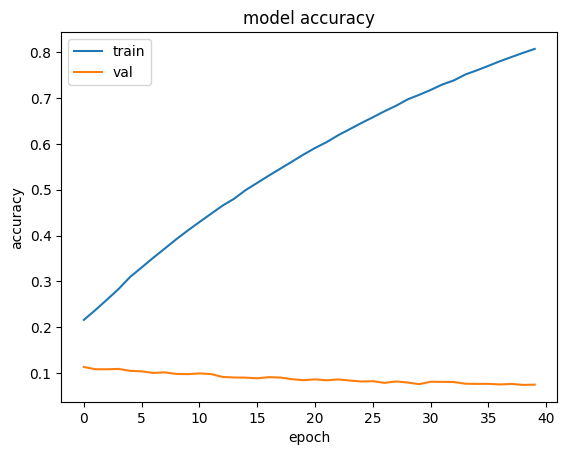

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

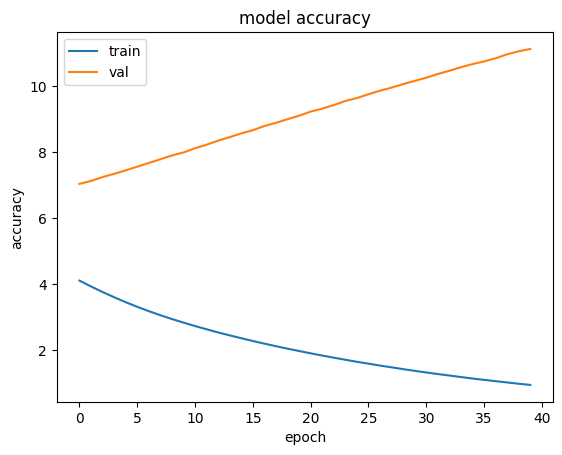

In [40]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [46]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_test_labels = np.argmax(y_test, axis=1)
y_predict_labels = np.argmax(y_predict, axis=1)

print("Accuracy:", accuracy_score(y_test_labels, y_predict_labels))

Accuracy: 0.11296952515946138
